**13/08/2026** -- Figure 5: Associations between deprivation and fire PM2.5 concentration in African countries.

Note that the figures being saved are for the 2000-2022 data.

In [1]:
Sys.setenv(PROJ_DATA = "/home/users/cho00/miniconda3/envs/ppca/share/proj")

In [2]:
library(dplyr)
library(readr)
library(tidyr)
library(stringr)
library(brms)
library(rstan)
library(cmdstanr)
library(sf)
library(ggplot2)
library(ggpattern)
library(forcats)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: Rcpp

Loading 'brms' package (version 2.22.0). Useful instructions
can be found by typing help('brms'). A more detailed introduction
to the package is available through vignette('brms_overview').


Attaching package: ‘brms’


The following object is masked from ‘package:stats’:

    ar


Loading required package: StanHeaders


rstan version 2.32.6 (Stan version 2.32.2)


For execution on a local, multicore CPU with excess RAM we recommend calling
options(mc.cores = parallel::detectCores()).
To avoid recompilation of unchanged Stan programs, we recommend calling
rstan_options(auto_write = TRUE)
For within-chain threading using `reduce_sum()` or `map_rect()` Stan functions,
change `threads_per_chain` option:
rstan_options(threads_per_chain = 1)



Attaching package

In [3]:
root <- rprojroot::find_root(rprojroot::has_file(".gitignore"))
source(file.path(root, "src/deprivation_pm_bhm/data_prep.R"))
source(file.path(root, "src/deprivation_pm_bhm/pca.R"))
source(file.path(root, "src/deprivation_pm_bhm/model_setup.R"))
source(file.path(root, "src/deprivation_pm_bhm/model_summary.R"))
source(file.path(root, "src/deprivation_pm_bhm/postprocess.R"))
source(file.path(root, "src/deprivation_pm_bhm/plotting.R"))
source(file.path(root, "src/utils/utils.R"))

In [4]:
SCRATCH_DIR <- Sys.getenv("SCRATCH_DIR")
# DATA_PATH   <- file.path(SCRATCH_DIR, 
#                          "data/spatial/fire_pm_dep_paper_data",
#                          "proc_data/df_af_annual_2000_2023.csv")
NAT_BOUNDS_PATH     <- file.path(SCRATCH_DIR, 
                         "data/spatial/nat_boundaries",
                         "WB_countries_Admin0_10m")
western_sahara_path <- file.path(SCRATCH_DIR, 
                         "data/spatial/nat_boundaries",
                         "western_sahara/gadm41_ESH_0.shp")

In [5]:
nat_bounds <- read_sf(NAT_BOUNDS_PATH)
esh_bounds <- read_sf(western_sahara_path)

In [6]:
# Function to post-process model
postprocess <- function(model, df, nat_bounds) {
    draws   <- as_draws_df(model)

    # PC1 effects in U & R (draws)
    pc1_draws_ur <- extract_pc1_draws_ur(draws)      
    
    # Posterior summary by country & U/R
    slopes_ur <- summarise_draws(
        pc1_draws_ur, 
        pivot = TRUE, pivot_cols = c("rural", "urban"),
        names_to = "urban_rural_cat",
        group_vars = c("country", "urban_rural_cat", "term")
    )
    
    # Post-stratification: p-w avg of U & R PC1 draws
    pc1_draws_pw_avg <- compute_pw_pc1_draws(pc1_draws_ur, df)
    
    # Posterior summary of U/R pooled effects draws
    slopes_pw_avg <- summarise_draws( 
        pc1_draws_pw_avg, 
        pivot = TRUE, pivot_cols = c("pooled"),
        names_to = "urban_rural_cat",
        group_vars = c("country", "urban_rural_cat", "term")
    )

    # Join to nat bounds
    sf_slopes_ur <- nat_bounds %>%
        select(WB_NAME, SUBREGION, geometry) %>%
        right_join( slopes_ur, by = c("WB_NAME" = "country") )

    sf_slopes_pw_avg <- nat_bounds |> 
        select(WB_NAME, SUBREGION, geometry) %>%
        right_join( slopes_pw_avg, by = c("WB_NAME" = "country") )

    list(
        "slopes_ur"     = slopes_ur,
        "slopes_pw_avg" = slopes_pw_avg,
        "sf_slopes_ur"  = sf_slopes_ur,
        "sf_slopes_pw_avg"  = sf_slopes_pw_avg,
        "pc1_draws_ur"  = pc1_draws_ur,
        "pc1_draws_pw_avg" = pc1_draws_pw_avg
    )
}

#### Model for 2000-2022
With imputed socioeconomic data

In [7]:
# Load config
cfg             <- yaml::read_yaml(file.path(root, "configs/bhm_fit_ppca_hu_15kiter_24threads_cfg.yaml"))
data_filepath   <- cfg$project$data_filepath
model_save_dir  <- cfg$project$model_save_dir

In [8]:
set_cmdstan_path(cfg$environment$cmdstan_path)

CmdStan path set to: /home/users/cho00/miniconda3/envs/ppca/bin/cmdstan



In [9]:
# Construct model file path
model_file <- build_modelfile(
    out_path    = model_save_dir,
    model_name  = cfg$model$name,
    outcome     = cfg$model$outcome,
    scale_y     = cfg$data$scale_y,
    pca_method  = cfg$pca$method,
    n_pcs       = cfg$pca$n_pcs,    
    mcmc_cfg    = cfg$mcmc,
    priors_cfg  = cfg$priors,
    max_year    = cfg$data$max_year
)

In [10]:
# Load model
model <- readRDS(model_file)

In [11]:
# Load data
df <- readr::read_csv(data_filepath) |>
    filter(year <= cfg$data$max_year) |>
    group_by(lon, lat) |>
    mutate(grid_id = cur_group_id()) |> # create grid_id for projecting SE vars
    ungroup()

Rows: 994412 Columns: 74
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (11): geometry, ISO_A3, country, region, continent, INCOME_GRP, ECONOMY,...
dbl (63): lon, lat, total_PM25, total_O3, fire_PM25, fire_O3, fire_PM25_hu, ...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [12]:
# Impute missing 2018-2022 socioeconomic indicators
df <- project_indicators(df, cfg$data$indicator_projections)

[1] "Projecting edu_mean_years forward from 2017"


Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.0227167 (tol = 0.002, component 1)”
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model is nearly unidentifiable: very large eigenvalue
 - Rescale variables?”


[1] "Projecting imp_san_access_pct forward from 2017"


Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.00349425 (tol = 0.002, component 1)”


[1] "Projecting stunting_pct_u5 forward from 2017"


Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.0278442 (tol = 0.002, component 1)”
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model is nearly unidentifiable: very large eigenvalue
 - Rescale variables?”


In [13]:
# Do PCA
pca_res <- compute_pca(
    df,
    method          = cfg$pca$method,
    se_indicators   = cfg$data$se_indicators,
    n_pcs           = cfg$pca$n_pcs,
    scale           = cfg$pca$scale,
    centre          = cfg$pca$centre,
    seed            = cfg$pca$seed,
    positive_vars   = cfg$pca$pc1_positive_loadings,
    negative_vars   = cfg$pca$pc1_negative_loadings
)

Warning message:
“Using an external vector in selections was deprecated in tidyselect 1.1.0.
ℹ Please use `all_of()` or `any_of()` instead.
  # Was:
  data %>% select(se_indicators)

  # Now:
  data %>% select(all_of(se_indicators))

See <https://tidyselect.r-lib.org/reference/faq-external-vector.html>.”
[2026-08-14 09:48:40] Flipping PC1 so higher = more deprivation



In [14]:
# Join PCs back onto df (helper funct)
df  <- prepare_analysis_data(df, 
                             pca_res$data, 
                             outcome = "fire_PM25_hu", 
                             scale_y = cfg$data$scale_y,
                             scale_PC1 = cfg$data$scale_PC1)

In [15]:
slopes <- postprocess(model, df, nat_bounds)

Warning message:
“Dropping 'draws_df' class as required metadata was removed.”
Warning message:
“Dropping 'draws_df' class as required metadata was removed.”
Warning message:
“Dropping 'draws_df' class as required metadata was removed.”
Warning message:
“Dropping 'draws_df' class as required metadata was removed.”


##### Fig 5a: forestplot

In [16]:
# Forest plot
forest_data <- slopes$slopes_ur %>%
    bind_rows(slopes$slopes_pw_avg) %>%
    filter(term == "PC1") %>%
    mutate(
        country = recode(country,
            "eSwatini"                        = "Eswatini",
            "Congo, Democratic Republic of"   = "DR Congo",
            "Egypt, Arab Republic of"         = "Egypt"
        ),
        # country = forcats::fct_relevel(country, "Pooled, all countries"),
        urban_rural_cat = recode(urban_rural_cat,
                                "pooled" = "Pooled",
                                "rural" = "Rural", "urban" = "Urban"),
        country = forcats::fct_relevel(
            forcats::fct_reorder(country, estimate, .desc = TRUE),
            "Pooled, all countries",
            after = Inf
        ),
        facet_group = dplyr::case_when( # create a faceting variable for the two forestplot panels -- one with pooled effects, one with urban and rural # nolint
            urban_rural_cat == "Pooled" ~ "Pooled urban & rural",
            TRUE                        ~ "Stratified urban & rural"
        )
    )

In [17]:
options(repr.plot.height = 14, repr.plot.width = 12)

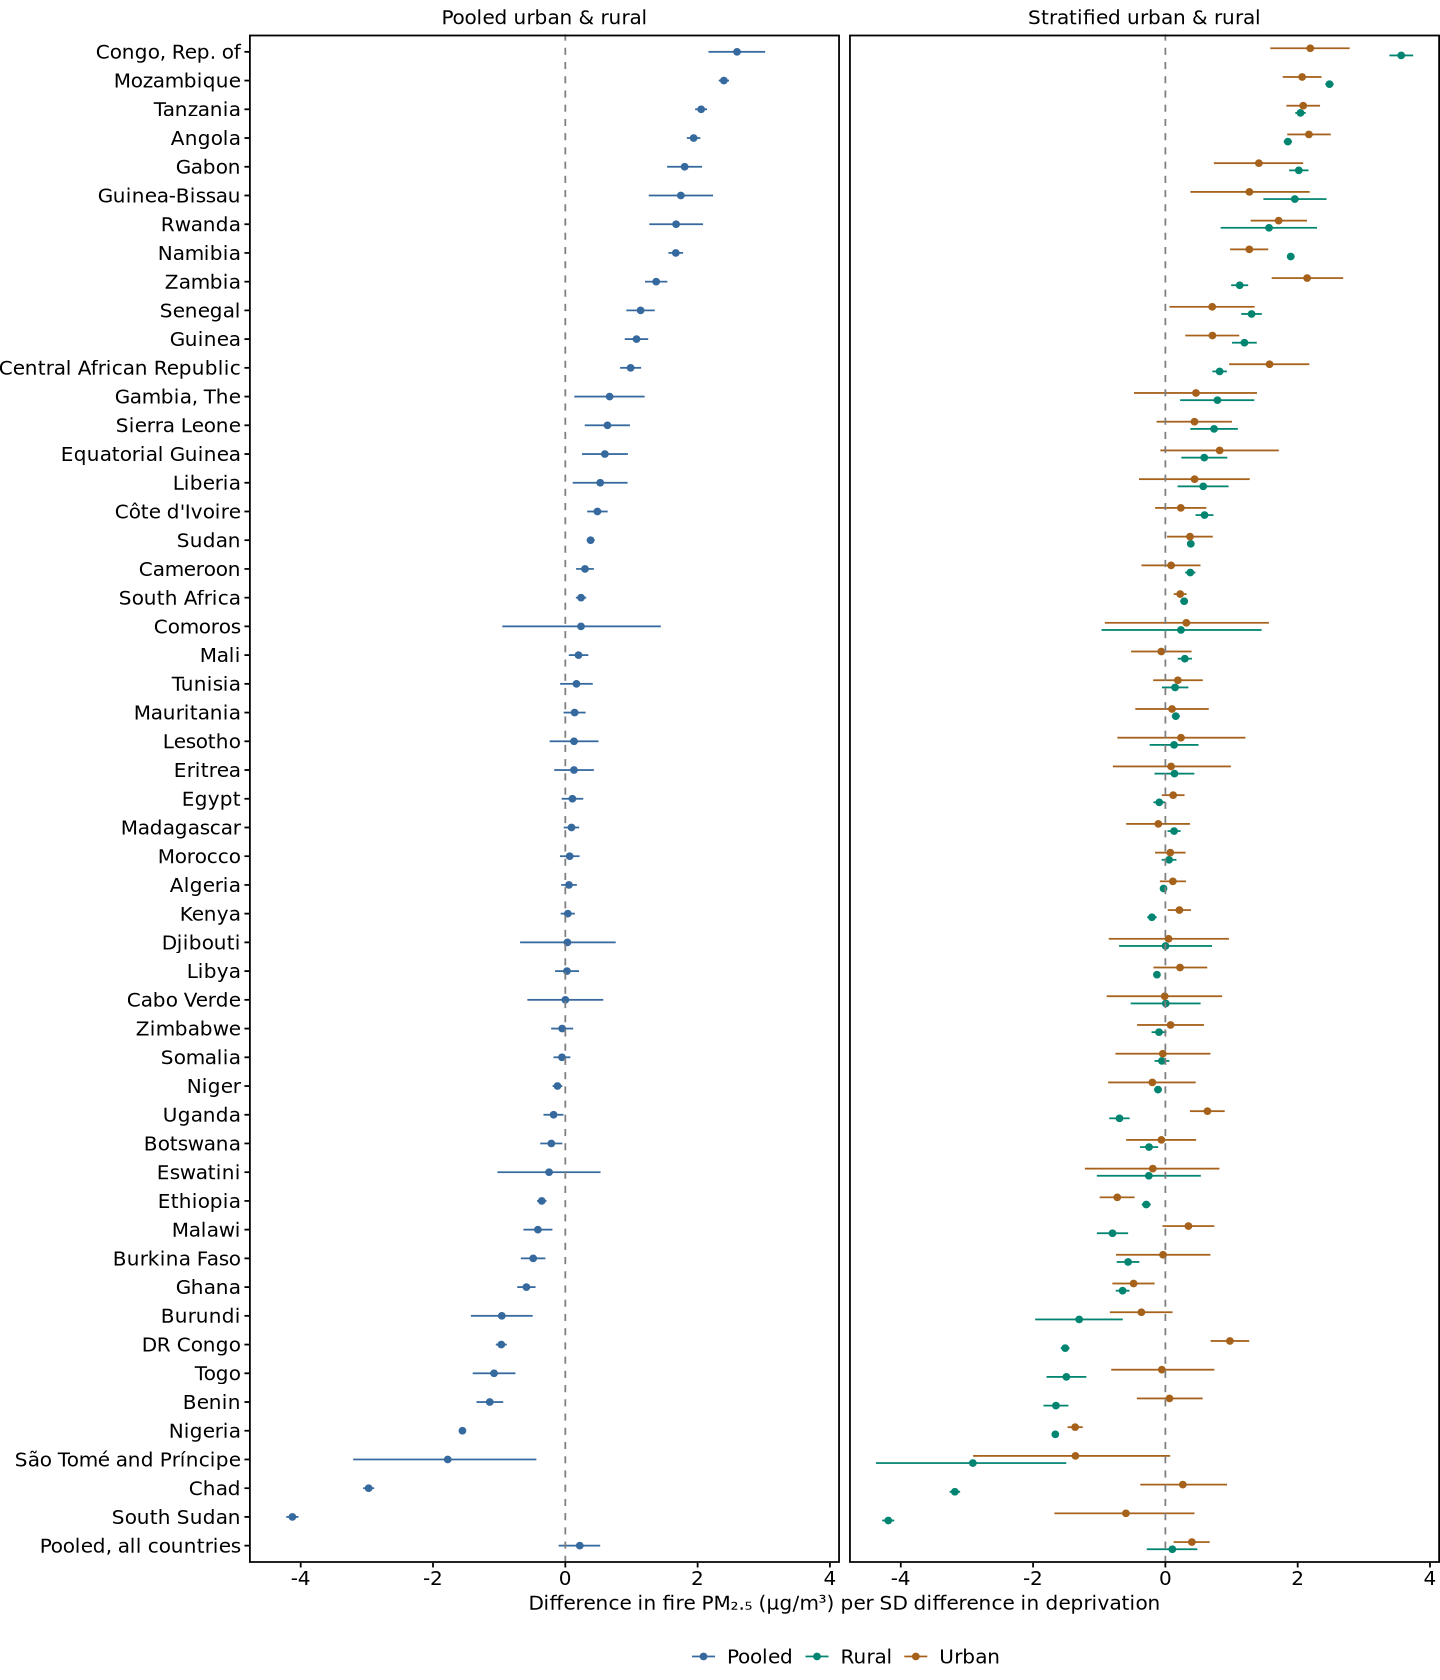

In [18]:
forestplot_fig <- ggplot(
    data = forest_data,
    mapping = aes(
        x     = estimate,
        y     = fct_rev(country),
        color = urban_rural_cat
    )
) +
    facet_wrap(~ facet_group) +
    geom_point(position = position_dodge(width = 0.5)) +
    geom_errorbarh(
        aes(xmin = conf.low, xmax = conf.high),
        height   = 0,
        position = position_dodge(width = 0.5)
    ) +
    scale_color_manual(values = c(
        "Pooled" = "#366A9FFF", # blue-ish (mako)
        "Rural"  = "#018571",   # teal
        "Urban"  = "#a6611a"    # brown
    )) +
    geom_vline(
        xintercept = 0,
        linetype   = "dashed",
        color      = "gray50"
    ) +
    labs(
        x     = "Difference in fire PM₂.₅ (μg/m³) per SD difference in deprivation",    #nolint
        y     = NULL,
        color = NULL,
        title = NULL
    ) +
    theme_minimal() +
    theme(
        legend.position      = "bottom",
        # legend.box.spacing   = unit(-8, "pt"),
        legend.title         = element_blank(),
        legend.text          = element_text(color = "black", size = 12),
        panel.border         = element_rect(color = "black", fill = NA, linewidth = 1), # nolint
        axis.ticks           = element_line(color = "black"),
        panel.grid.major     = element_blank(),
        panel.grid.minor     = element_blank(),
        axis.title           = element_text(color = "black", size = 12),
        axis.text            = element_text(color = "black", size = 12),
        strip.text           = element_text(color = "black", size = 12),
        plot.title           = element_blank(),
        plot.margin          = margin(0, 0, 0, 0)#30)  # left margin to stop Central African Republic getting clipped  # nolint
    )

forestplot_fig

In [19]:
ggsave(
    plot = forestplot_fig,
    filename = file.path(root, "paper_results/figures/fig_5a.png"),
    height = 14,
    width = 12,
    bg = "white",
    dpi = 450
)

##### Fig 5b: maps of coefficients

In [20]:
options(repr.plot.height = 8, repr.plot.width = 16)

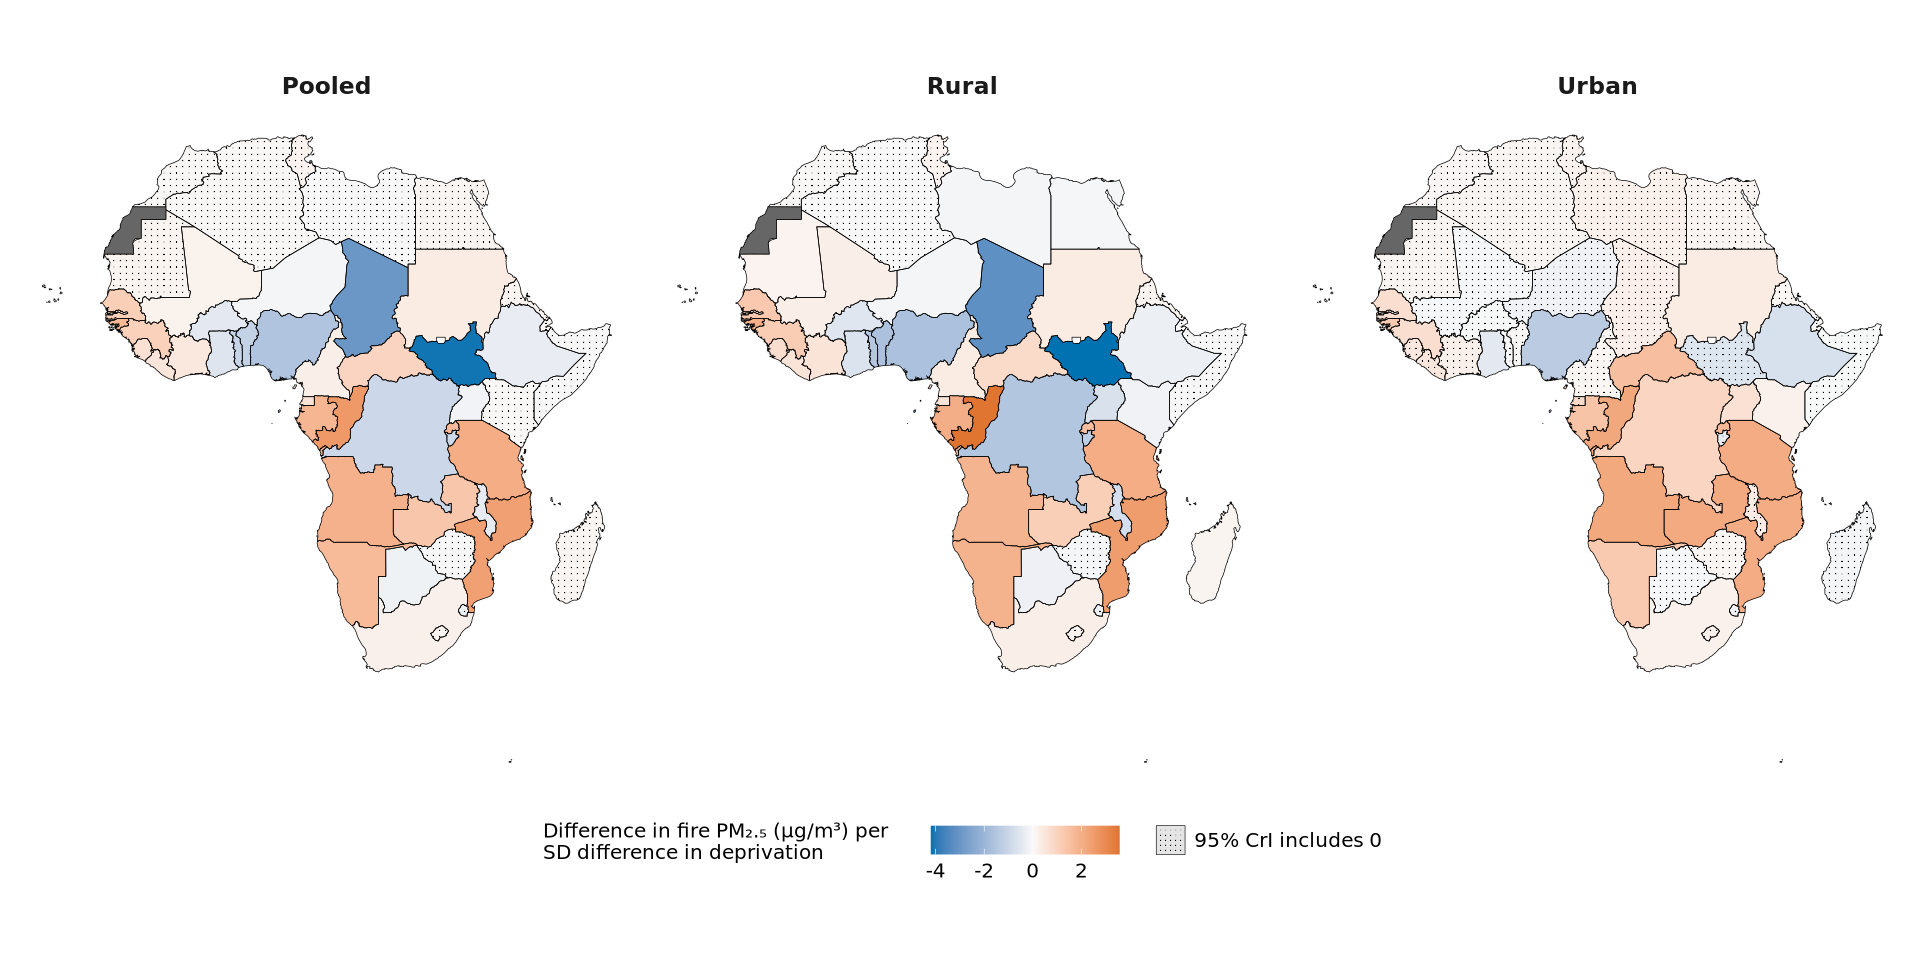

In [21]:
map_fig <- map_country_effects(
    bind_rows(
        slopes$sf_slopes_ur |> 
            mutate(urban_rural_cat = recode(
                urban_rural_cat, "rural" = "Rural", "urban" = "Urban"
            )),
        slopes$sf_slopes_pw_avg |> 
            mutate(urban_rural_cat = recode(
                urban_rural_cat, "pooled" = "Pooled"
            )),
    ),
    variable_name    = "PC1",
    urban_rural_var  = "urban_rural_cat",
    fill_name        = "Difference in fire PM₂.₅ (μg/m³) per\nSD difference in deprivation",
    pattern_name     = NULL,
    facet_ncol       = 3,
    # palette_low = "#b35806", 
    # palette_mid = "#F7F7F7",
    # palette_high = "#542788",
) +
    guides(
        fill    = guide_colorbar(order = 1, barwidth = unit(4, "cm")),
        pattern = guide_legend(order = 2)
    ) +
    theme(
        strip.text       = element_text(size = 14, face = "bold"),
        legend.position  = "bottom",
        legend.key.spacing.x = unit(0.5, "cm"),
        legend.title     = element_text(margin = margin(r = 25), size = 12, vjust = 1.1),   # nolint
        legend.text      = element_text(color = "black", size = 12)
    ) +
    geom_sf(data = esh_bounds, color = "black", fill = "gray40")
map_fig

In [22]:
ggsave(
    plot = map_fig,
    filename = file.path(root, "paper_results/figures/fig_5b.png"),
    height = 8,
    width = 16,
    bg = "white",
    dpi = 450
)

#### Model for 2000-2017
With imputed socioeconomic data

In [30]:
# Load config
cfg             <- yaml::read_yaml(file.path(root, "configs/bhm_fit_ppca_hu_2000_2017_15kiter_24threads_cfg.yaml"))
data_filepath   <- cfg$project$data_filepath
model_save_dir  <- cfg$project$model_save_dir

In [31]:
set_cmdstan_path(cfg$environment$cmdstan_path)

CmdStan path set to: /home/users/cho00/miniconda3/envs/ppca/bin/cmdstan



In [32]:
# Construct model file path
model_file <- build_modelfile(
    out_path    = model_save_dir,
    model_name  = cfg$model$name,
    outcome     = cfg$model$outcome,
    scale_y     = cfg$data$scale_y,
    pca_method  = cfg$pca$method,
    n_pcs       = cfg$pca$n_pcs,    
    mcmc_cfg    = cfg$mcmc,
    priors_cfg  = cfg$priors,
    max_year    = cfg$data$max_year
)

In [34]:
# Load model
model <- readRDS(model_file)

In [35]:
# Load data
df <- readr::read_csv(data_filepath) |>
    filter(year <= cfg$data$max_year) |>
    group_by(lon, lat) |>
    mutate(grid_id = cur_group_id()) |> # create grid_id for projecting SE vars
    ungroup()

Rows: 994412 Columns: 74
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (11): geometry, ISO_A3, country, region, continent, INCOME_GRP, ECONOMY,...
dbl (63): lon, lat, total_PM25, total_O3, fire_PM25, fire_O3, fire_PM25_hu, ...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [36]:
# Do PCA
pca_res <- compute_pca(
    df,
    method          = cfg$pca$method,
    se_indicators   = cfg$data$se_indicators,
    n_pcs           = cfg$pca$n_pcs,
    scale           = cfg$pca$scale,
    centre          = cfg$pca$centre,
    seed            = cfg$pca$seed,
    positive_vars   = cfg$pca$pc1_positive_loadings,
    negative_vars   = cfg$pca$pc1_negative_loadings
)

In [37]:
# Join PCs back onto df (helper funct)
df  <- prepare_analysis_data(df, 
                             pca_res$data, 
                             outcome = "fire_PM25_hu", 
                             scale_y = cfg$data$scale_y,
                             scale_PC1 = cfg$data$scale_PC1)

In [38]:
slopes <- postprocess(model, df, nat_bounds)

Warning message:
“Dropping 'draws_df' class as required metadata was removed.”
Warning message:
“Dropping 'draws_df' class as required metadata was removed.”
Warning message:
“Dropping 'draws_df' class as required metadata was removed.”
Warning message:
“Dropping 'draws_df' class as required metadata was removed.”


##### Fig 5a: forestplot

In [39]:
# Forest plot
forest_data <- slopes$slopes_ur %>%
    bind_rows(slopes$slopes_pw_avg) %>%
    filter(term == "PC1") %>%
    mutate(
        country = recode(country,
            "eSwatini"                        = "Eswatini",
            "Congo, Democratic Republic of"   = "DR Congo",
            "Egypt, Arab Republic of"         = "Egypt"
        ),
        # country = forcats::fct_relevel(country, "Pooled, all countries"),
        urban_rural_cat = recode(urban_rural_cat,
                                "pooled" = "Pooled",
                                "rural" = "Rural", "urban" = "Urban"),
        country = forcats::fct_relevel(
            forcats::fct_reorder(country, estimate, .desc = TRUE),
            "Pooled, all countries",
            after = Inf
        ),
        facet_group = dplyr::case_when( # create a faceting variable for the two forestplot panels -- one with pooled effects, one with urban and rural # nolint
            urban_rural_cat == "Pooled" ~ "Pooled urban & rural",
            TRUE                        ~ "Stratified urban & rural"
        )
    )

In [40]:
options(repr.plot.height = 14, repr.plot.width = 12)

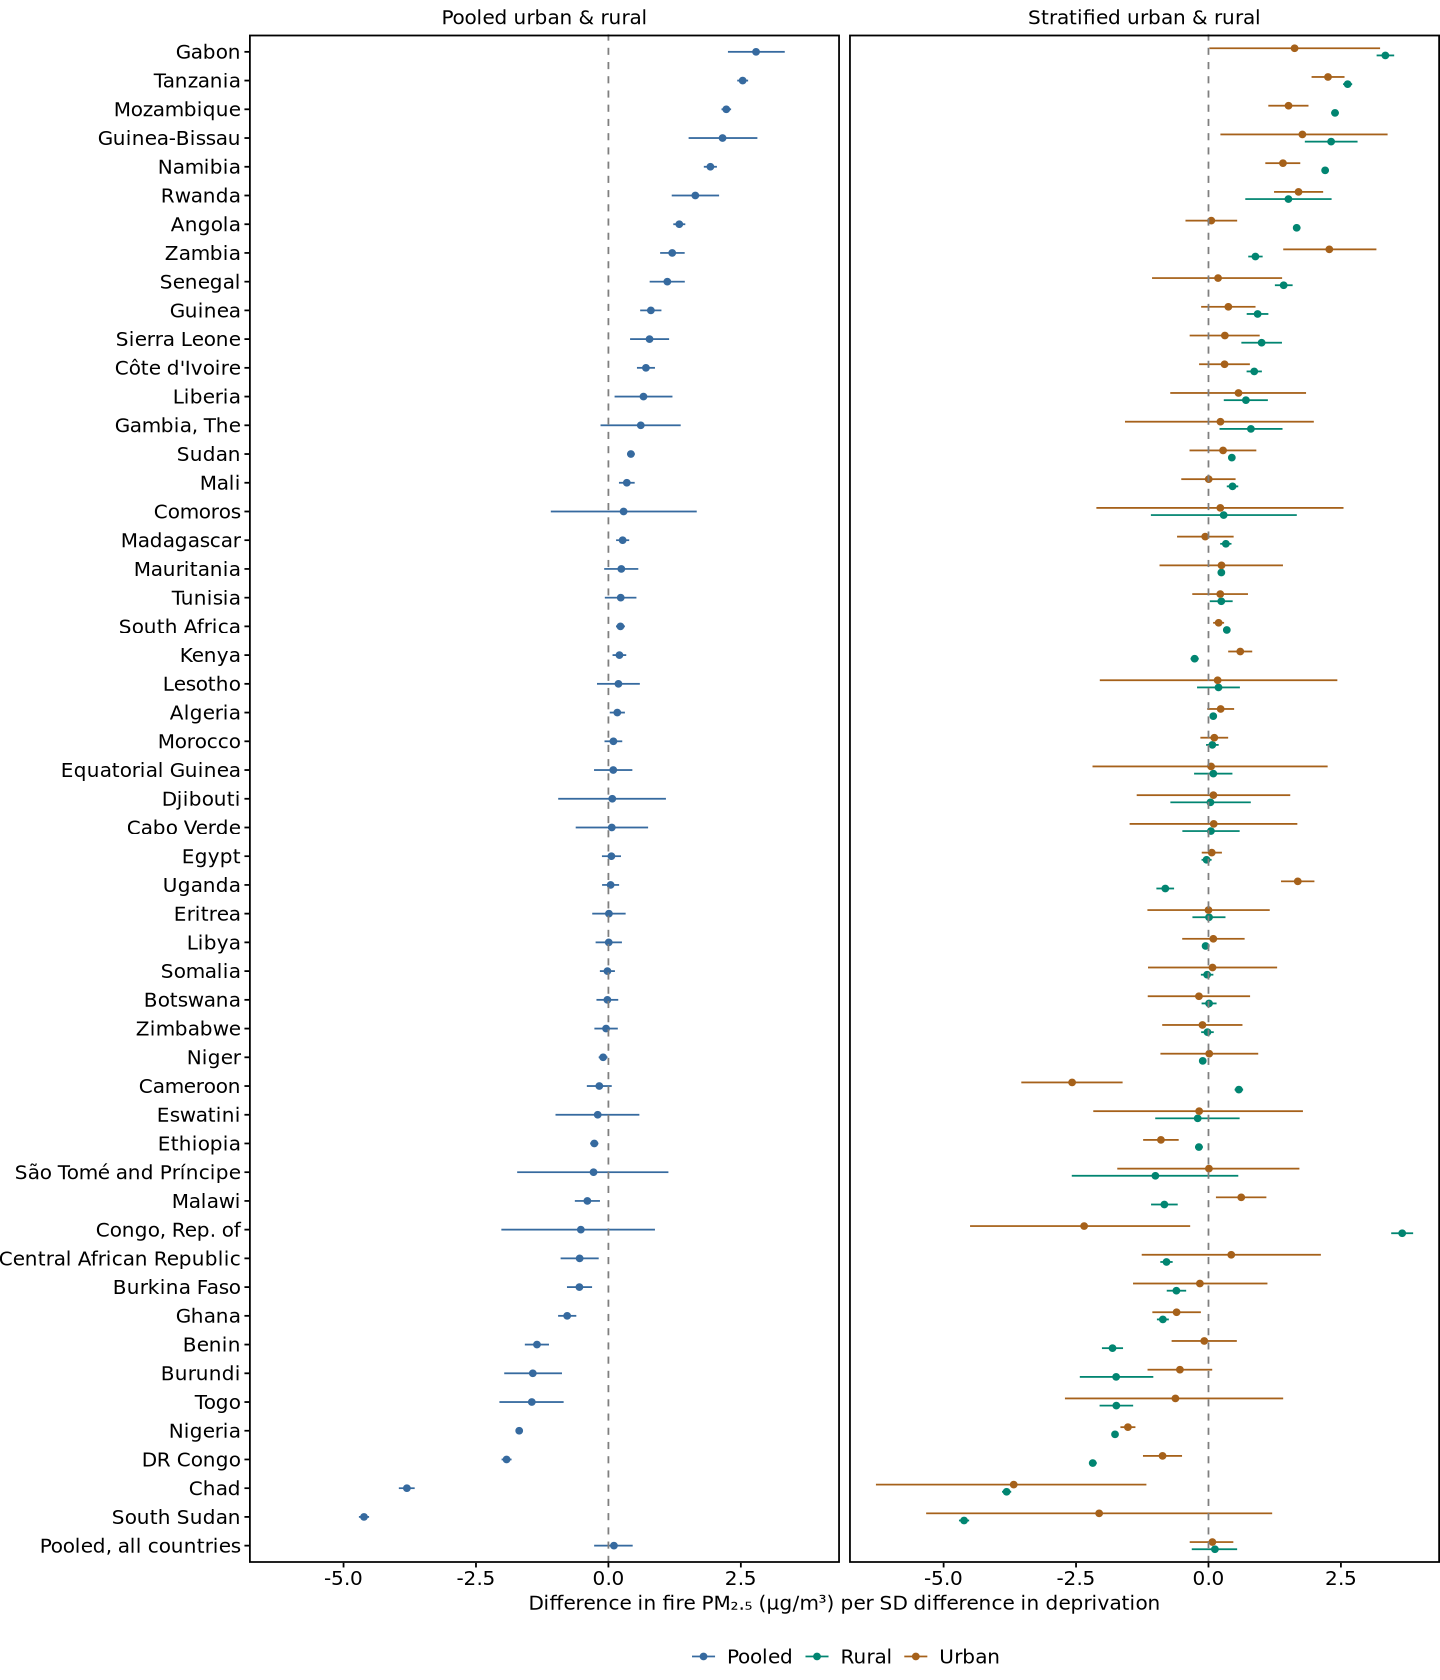

In [41]:
forestplot_fig <- ggplot(
    data = forest_data,
    mapping = aes(
        x     = estimate,
        y     = fct_rev(country),
        color = urban_rural_cat
    )
) +
    facet_wrap(~ facet_group) +
    geom_point(position = position_dodge(width = 0.5)) +
    geom_errorbarh(
        aes(xmin = conf.low, xmax = conf.high),
        height   = 0,
        position = position_dodge(width = 0.5)
    ) +
    scale_color_manual(values = c(
        "Pooled" = "#366A9FFF", # blue-ish (mako)
        "Rural"  = "#018571",   # teal
        "Urban"  = "#a6611a"    # brown
    )) +
    geom_vline(
        xintercept = 0,
        linetype   = "dashed",
        color      = "gray50"
    ) +
    labs(
        x     = "Difference in fire PM₂.₅ (μg/m³) per SD difference in deprivation",    #nolint
        y     = NULL,
        color = NULL,
        title = NULL
    ) +
    theme_minimal() +
    theme(
        legend.position      = "bottom",
        # legend.box.spacing   = unit(-8, "pt"),
        legend.title         = element_blank(),
        legend.text          = element_text(color = "black", size = 12),
        panel.border         = element_rect(color = "black", fill = NA, linewidth = 1), # nolint
        axis.ticks           = element_line(color = "black"),
        panel.grid.major     = element_blank(),
        panel.grid.minor     = element_blank(),
        axis.title           = element_text(color = "black", size = 12),
        axis.text            = element_text(color = "black", size = 12),
        strip.text           = element_text(color = "black", size = 12),
        plot.title           = element_blank(),
        plot.margin          = margin(0, 0, 0, 0)#30)  # left margin to stop Central African Republic getting clipped  # nolint
    )

forestplot_fig

In [42]:
# ggsave(
#     plot = forestplot_fig,
#     filename = file.path(root, "paper_results/figures/fig_5a.png"),
#     height = 14,
#     width = 12,
#     bg = "white",
#     dpi = 450
# )

##### Fig 5b: maps of coefficients

In [43]:
options(repr.plot.height = 8, repr.plot.width = 16)

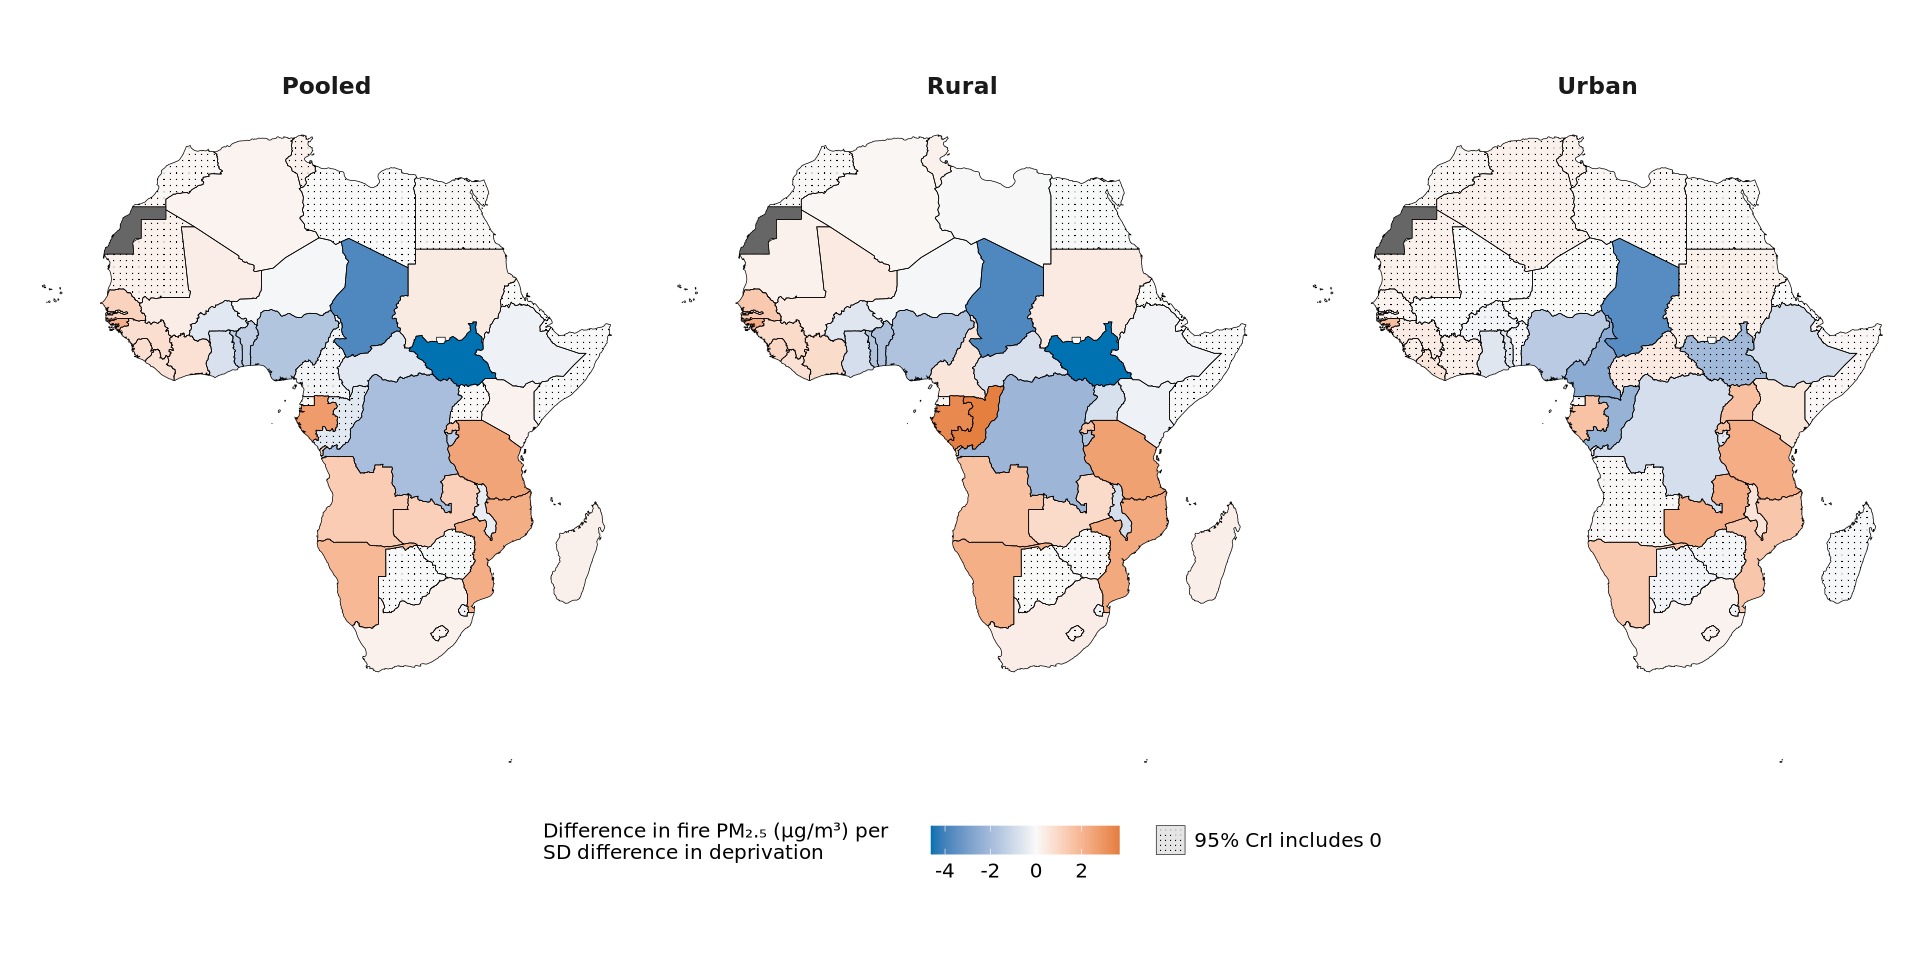

In [44]:
map_fig <- map_country_effects(
    bind_rows(
        slopes$sf_slopes_ur |> 
            mutate(urban_rural_cat = recode(
                urban_rural_cat, "rural" = "Rural", "urban" = "Urban"
            )),
        slopes$sf_slopes_pw_avg |> 
            mutate(urban_rural_cat = recode(
                urban_rural_cat, "pooled" = "Pooled"
            )),
    ),
    variable_name    = "PC1",
    urban_rural_var  = "urban_rural_cat",
    fill_name        = "Difference in fire PM₂.₅ (μg/m³) per\nSD difference in deprivation",
    pattern_name     = NULL,
    facet_ncol       = 3,
    # palette_low = "#b35806", 
    # palette_mid = "#F7F7F7",
    # palette_high = "#542788",
) +
    guides(
        fill    = guide_colorbar(order = 1, barwidth = unit(4, "cm")),
        pattern = guide_legend(order = 2)
    ) +
    theme(
        strip.text       = element_text(size = 14, face = "bold"),
        legend.position  = "bottom",
        legend.key.spacing.x = unit(0.5, "cm"),
        legend.title     = element_text(margin = margin(r = 25), size = 12, vjust = 1.1),   # nolint
        legend.text      = element_text(color = "black", size = 12)
    ) +
    geom_sf(data = esh_bounds, color = "black", fill = "gray40")
map_fig

In [ ]:
# ggsave(
#     plot = map_fig,
#     filename = file.path(root, "paper_results/figures/fig_5b.png"),
#     height = 8,
#     width = 16,
#     bg = "white",
#     dpi = 450
# )